# Matplotlib is Pandas default plotting library

# Plotly is modern plotting library with a more interactive experience in Jupyter notebooks

In [5]:
import numpy as np
import pandas as pd
%matplotlib inline

In [3]:
%matplotlib notebook

In [7]:
data = pd.DataFrame(data = np.random.rand(4,4)*10000, 
                    index = ["Q1", "Q2", "Q3", "Q4"],
                    columns = ["East", "West", "North", "South"])

data.index.name = "Quarters"
data.columns.name = "Region"
data

Region,East,West,North,South
Quarters,,,,
Q1,6553.705945,5858.710123,2976.780729,2790.168677
Q2,7886.063751,1123.084898,1416.929091,1025.072669
Q3,4917.842121,6657.915116,7830.766917,2537.264050
Q4,7787.493138,463.191581,8612.979558,932.164651


<Axes: xlabel='Quarters'>

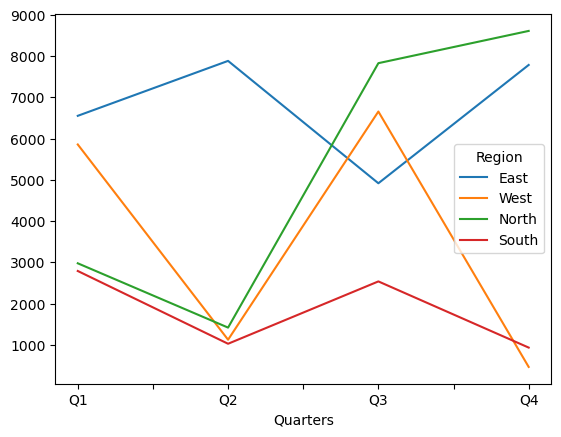

In [9]:
data.plot.line()

<Axes: xlabel='Quarters'>

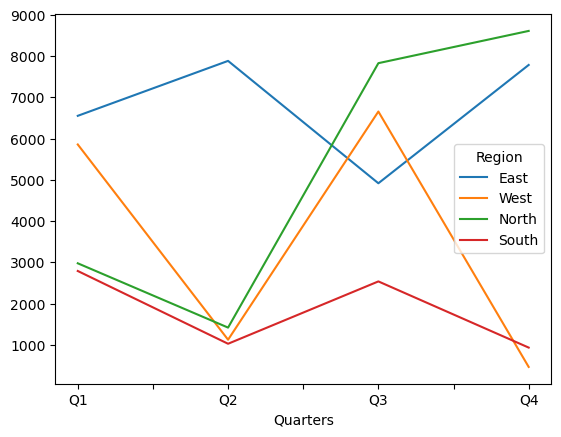

In [12]:
data.plot()

In [13]:
# %magic

In [14]:
# set the plotting backend to plotly

pd.options.plotting.backend = "plotly"

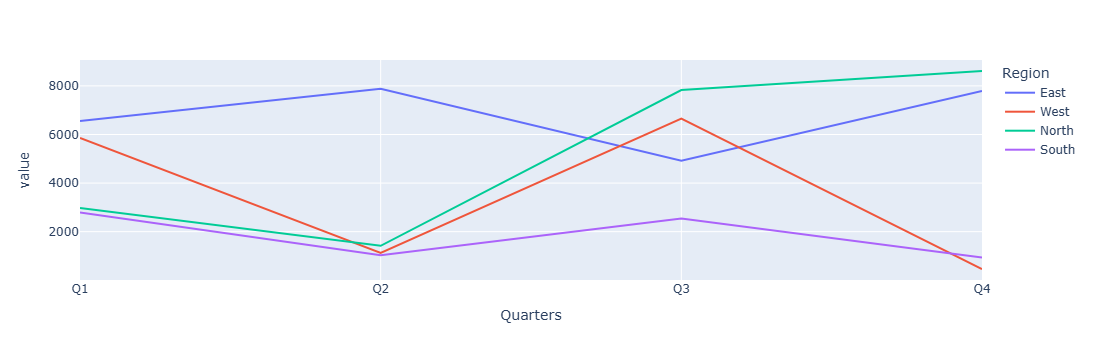

In [15]:
data.plot()

## bar vertical bar chart

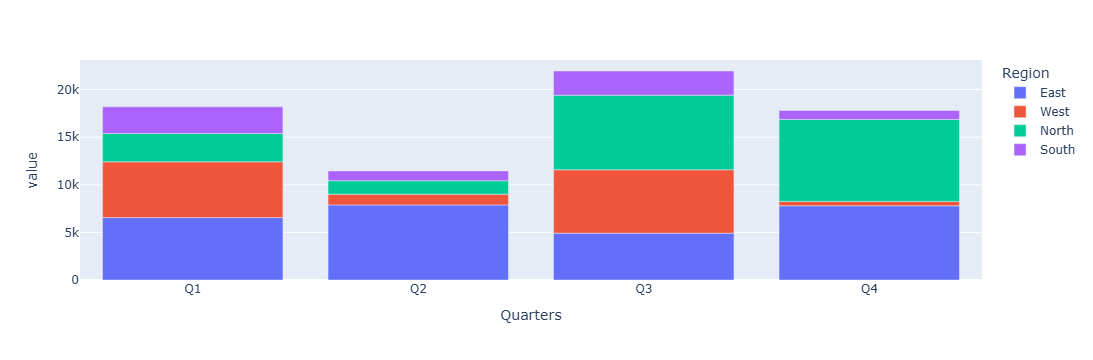

In [19]:
data.plot.bar()  # default barmode is "stack"

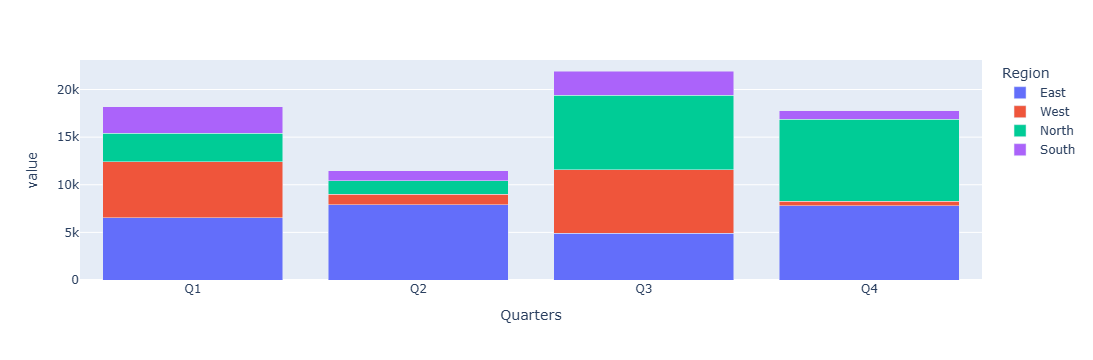

In [18]:
data.plot.bar(barmode="stack")

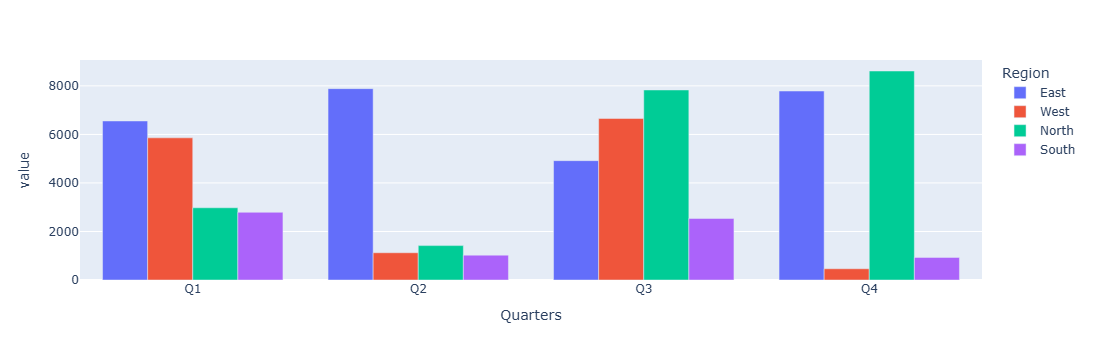

In [20]:
data.plot.bar(barmode="group")

## barh  horizontal bar chart

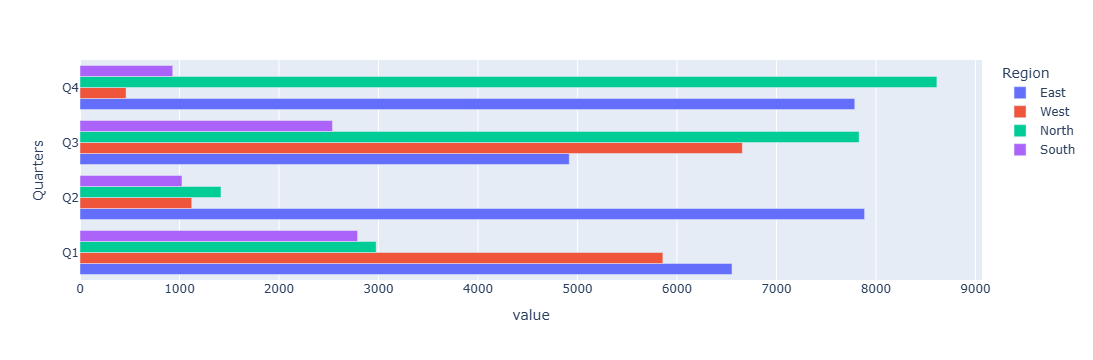

In [21]:
data.plot.barh(barmode="group")  

📊 **Pandas plot types**

| Type                  | Description                                   |
| --------------------- | --------------------------------------------- |
| `"line"`              | Line plot (default), good for time series     |
| `"bar"`               | Vertical bar chart                            |
| `"barh"`              | Horizontal bar chart                          |
| `"hist"`              | Histogram (distribution of values)            |
| `"box"`               | Box plot (quartiles, outliers)                |
| `"kde"` / `"density"` | Kernel density estimate (smooth distribution) |
| `"area"`              | Area plot (filled line plot)                  |
| `"pie"`               | Pie chart                                     |
| `"scatter"`           | Scatter plot (needs x and y)                  |
| `"hexbin"`            | Hexbin plot (for dense scatter data)          |


# ⚠ Key point

**Matplotlib backend** → all pandas plot types work (line, bar, hist, box, kde, area, scatter, hexbin, pie)

**Plotly backend** → only some plot types (line, bar, scatter, area, pie, histogram)

**kde / hexbin** → matplotlib only

In [27]:
import pandas as pd
import numpy as np

# Sample data
np.random.seed(42)
dates = pd.date_range("2026-01-01", periods=10)

df = pd.DataFrame({
    "Date": dates,
    "Sales": np.random.randint(50, 200, size=10),
    "Profit": np.random.randint(20, 100, size=10),
    "Expenses": np.random.randint(30, 150, size=10),
    "Category": list("ABCDEFGHIJ")
})

# Set Date as index for line/area plots
df.set_index("Date", inplace=True)

df

,Sales,Profit,Expenses,Category
Date,,,,
2026-01-01,152,43,50,A
2026-01-02,142,22,62,B
2026-01-03,64,41,105,C
2026-01-04,156,72,87,D
2026-01-05,121,21,51,E
2026-01-06,70,49,137,F
2026-01-07,152,57,118,G
2026-01-08,171,21,78,H
2026-01-09,124,83,120,I


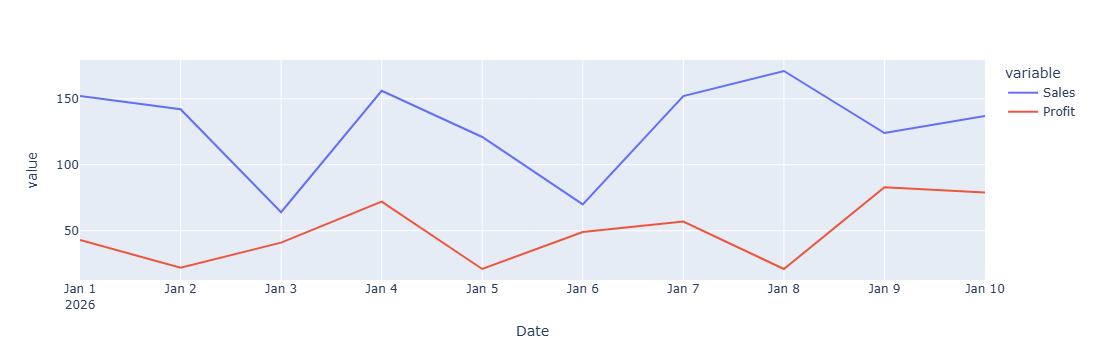

In [35]:
# line plot
df[["Sales","Profit"]].plot()   # default is the line plot
# df[["Sales","Profit"]].plot(kind="line")
# df[["Sales","Profit"]].plot.line()

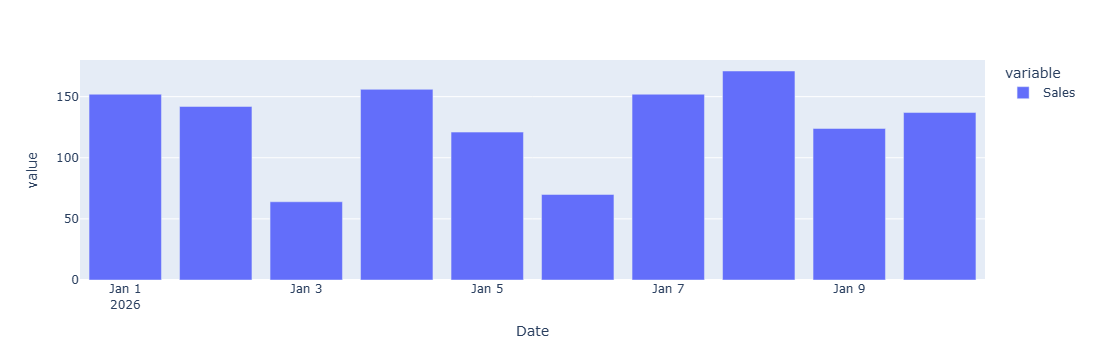

In [39]:
# Bar plot
df["Sales"].plot(kind="bar")
# df["Sales"].plot.bar()

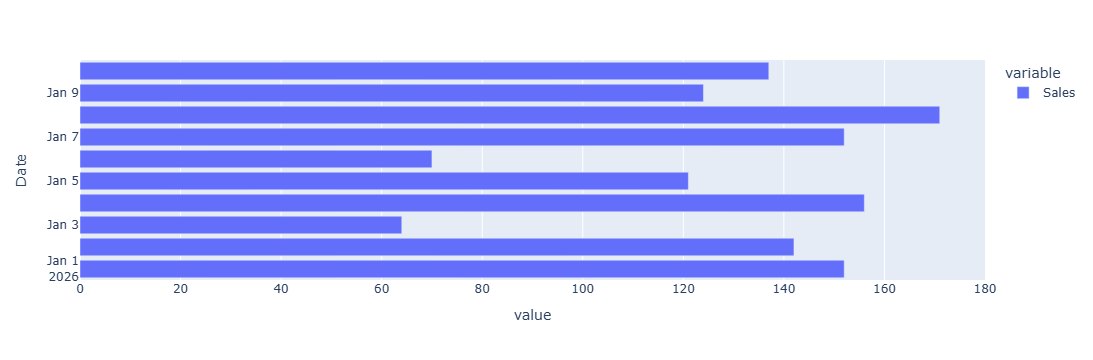

In [40]:
# Bar plot
df["Sales"].plot(kind="barh")
# df["Sales"].plot.barh()

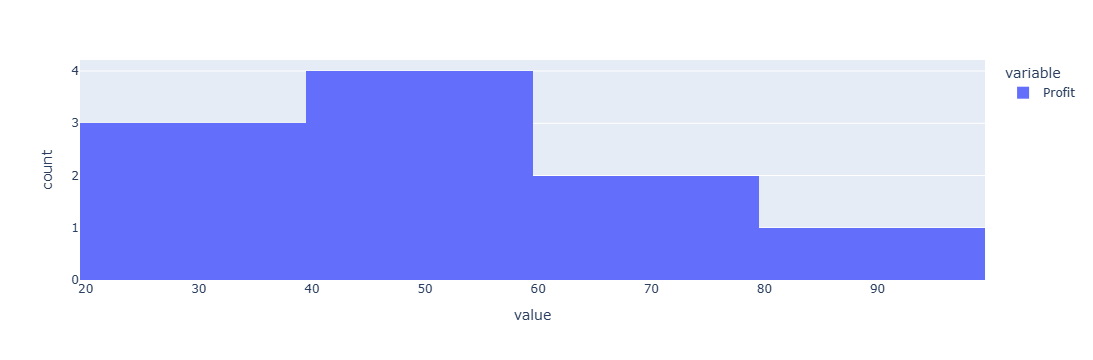

In [45]:
# Histogram
df["Profit"].plot(kind="hist", bins=4)

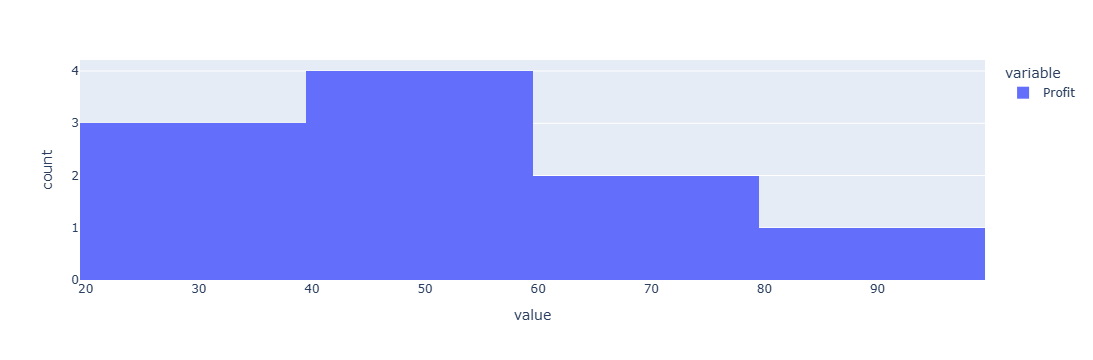

In [60]:
df["Profit"].plot.hist()

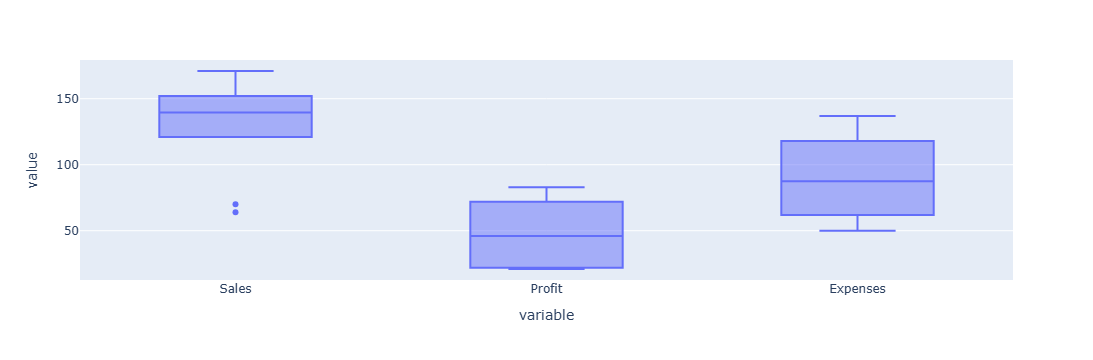

In [46]:
# Box plot
df[["Sales","Profit","Expenses"]].plot(kind="box")

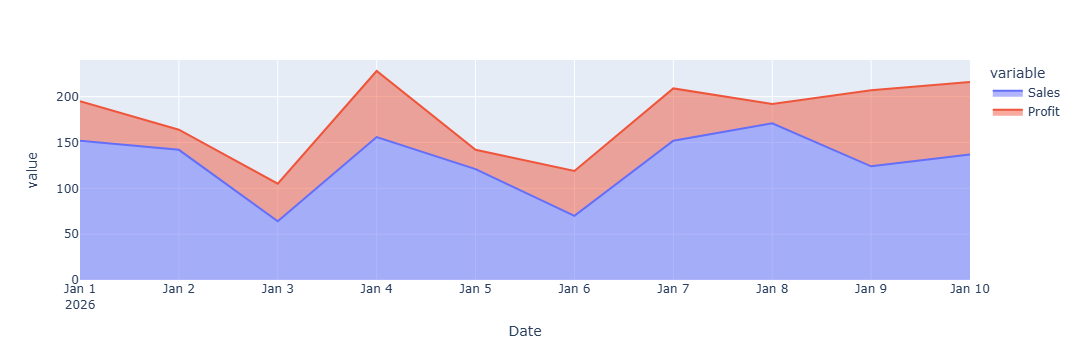

In [50]:
# Area plot
df[["Sales","Profit"]].plot(kind="area")

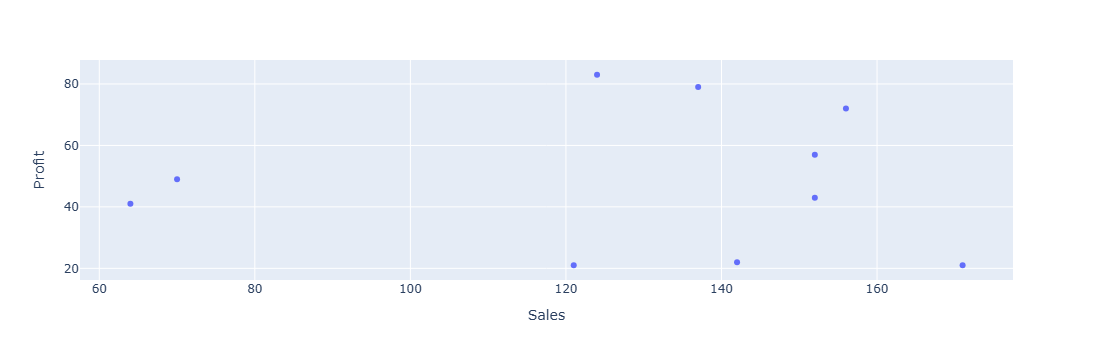

In [52]:
# Scatter plot
df.plot(kind="scatter", x="Sales", y="Profit")

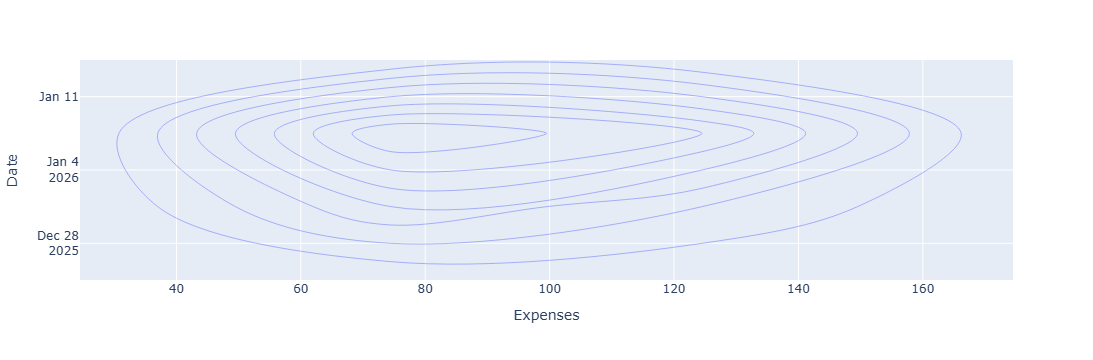

In [69]:
# KDE / Density plot ---

# Option 1: Use Plotly’s own API for density plots
import plotly.express as px

fig = px.density_contour(df, x="Expenses")
fig.show()

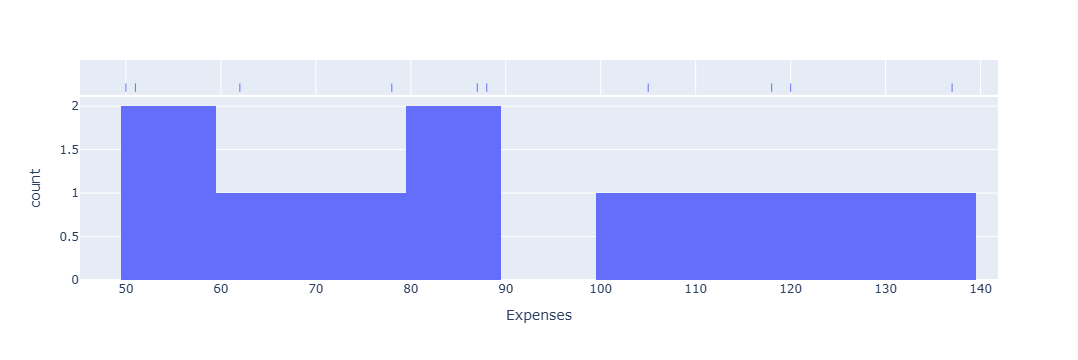

In [64]:
# or for smooth histogram:
fig = px.histogram(df, x="Expenses", marginal="rug", nbins=10)
fig.show()

# Switch pandas backend to matplotlib

<Axes: title={'center': 'KDE / Density Plot: Expenses'}, ylabel='Density'>

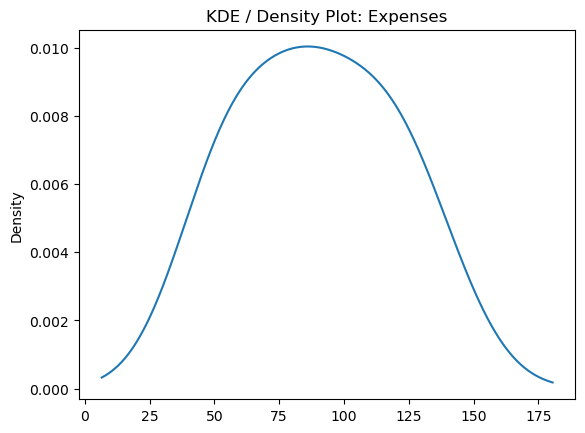

In [70]:
# Option 2: Switch pandas backend to matplotlib

pd.options.plotting.backend = "matplotlib"
# --- 6. KDE / Density plot ---
df["Expenses"].plot(kind="kde", title="KDE / Density Plot: Expenses")


<Axes: ylabel='Sales'>

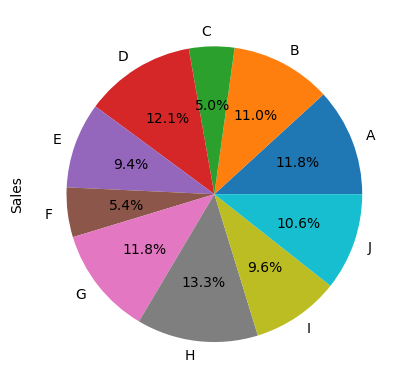

In [71]:
# Pie chart (single column)
df["Sales"].plot(kind="pie", labels=df["Category"], autopct="%1.1f%%")

<Axes: xlabel='Sales', ylabel='Profit'>

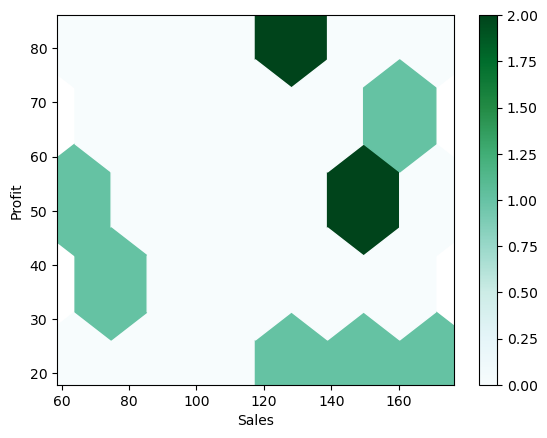

In [72]:
# Hexbin plot
df.plot(kind="hexbin", x="Sales", y="Profit", gridsize=5)


📊 **Other Plotting Libraries**

Seaborn     (https://oreil.ly/a3Ult)

Bokeh       (https://docs.bokeh.org) 

Altair      (https://oreil.ly/t06t7)

HoloViews   (https://holoviews.org)

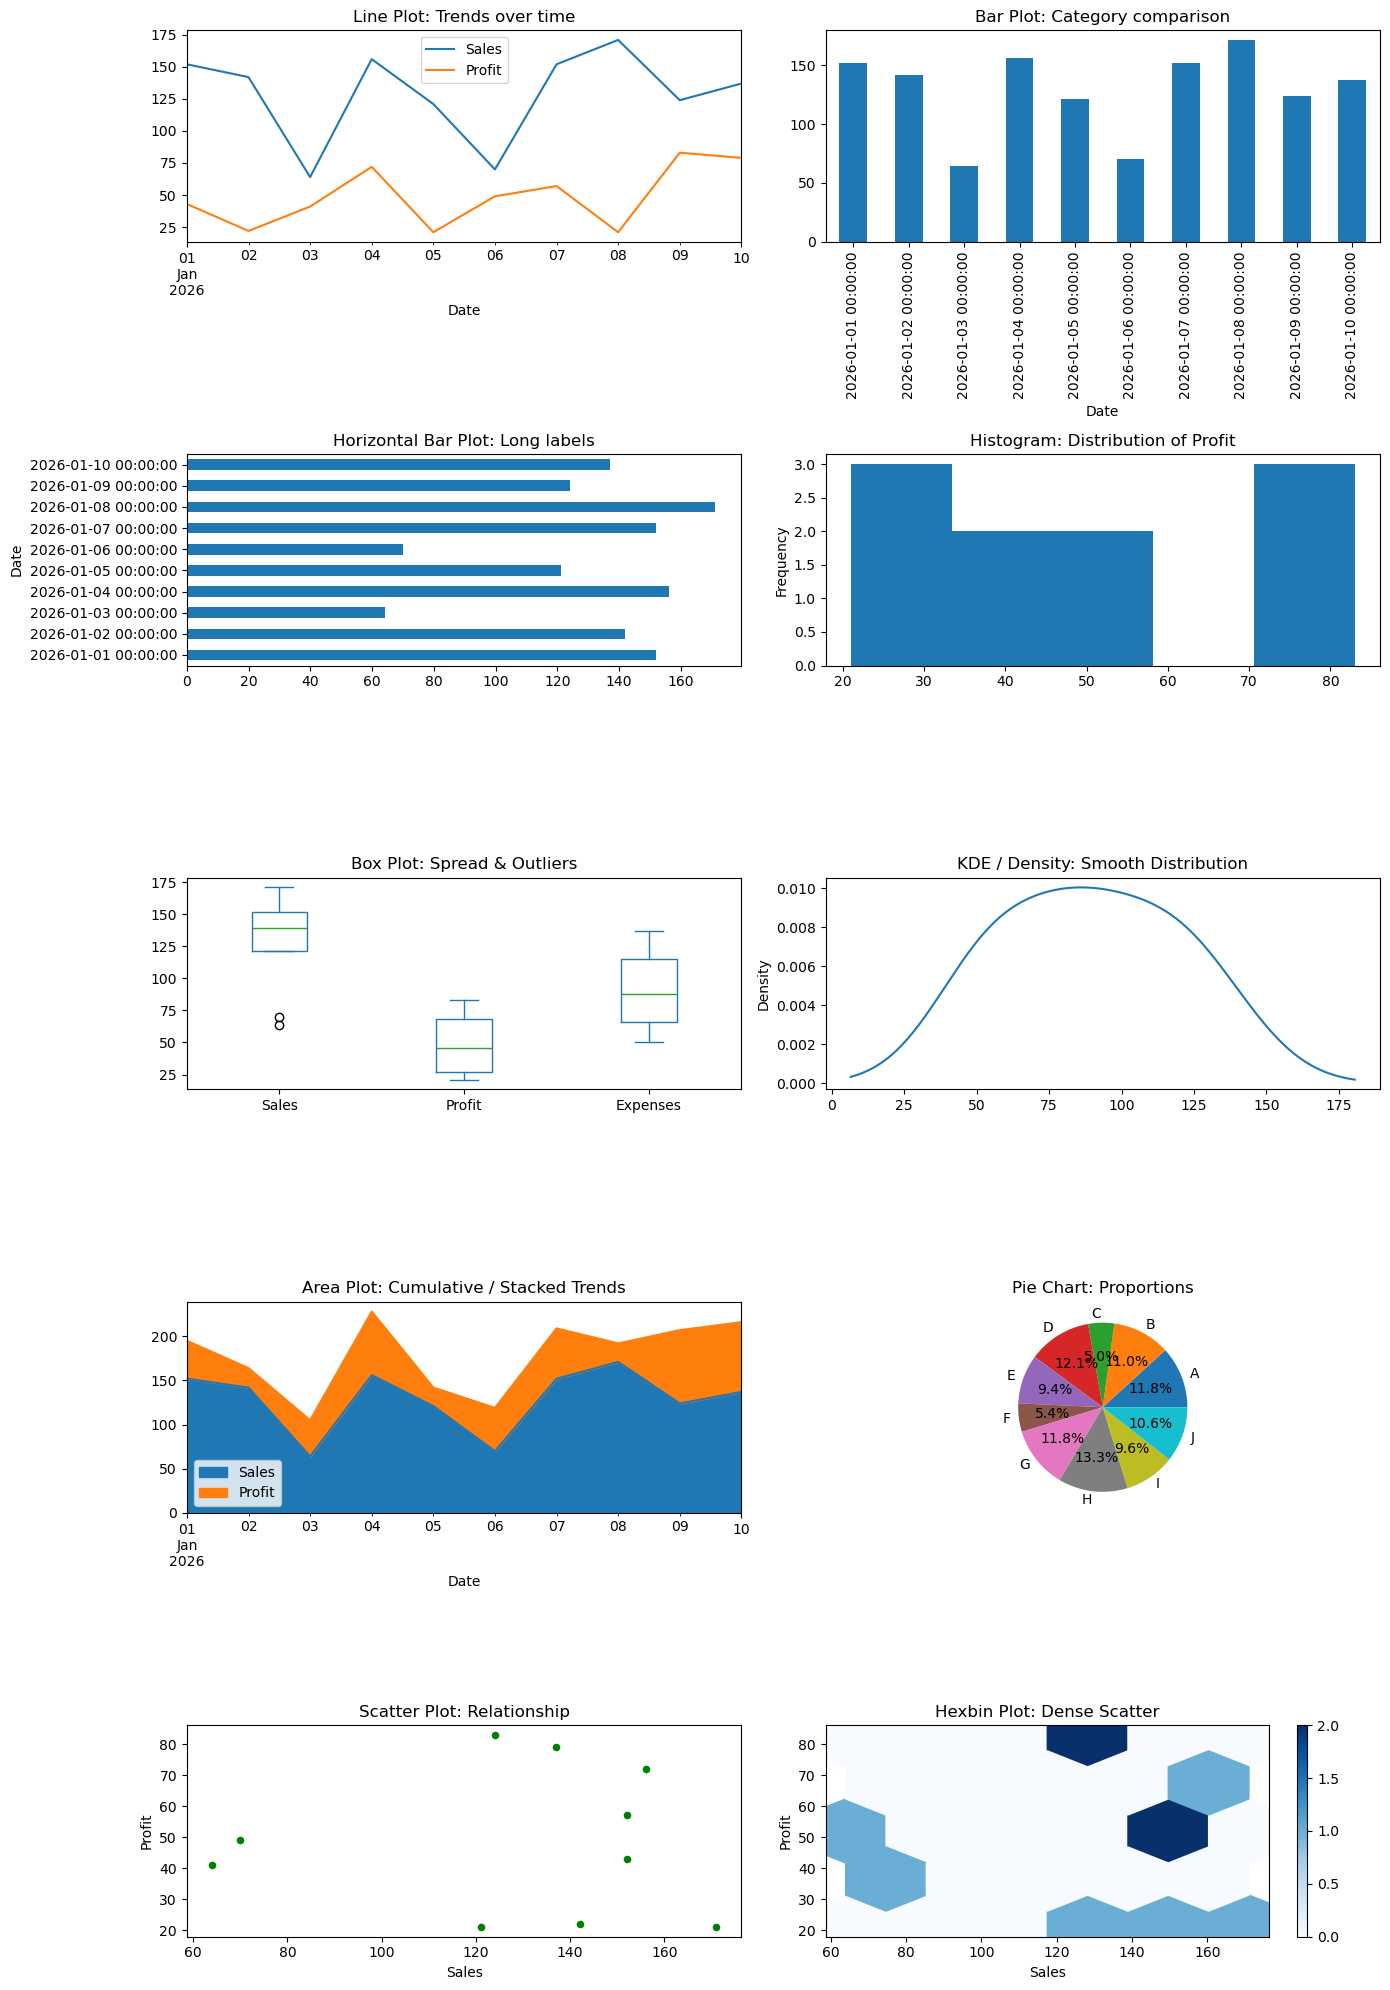

In [73]:
# 📌 Pandas Plotting Cheat Sheet: Visual Guide

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Sample Data ---
np.random.seed(42)
dates = pd.date_range("2026-01-01", periods=10)

df = pd.DataFrame({
    "Date": dates,
    "Sales": np.random.randint(50, 200, size=10),
    "Profit": np.random.randint(20, 100, size=10),
    "Expenses": np.random.randint(30, 150, size=10),
    "Category": list("ABCDEFGHIJ")
})

df.set_index("Date", inplace=True)

# --- Setup subplot grid ---
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

# 1️⃣ Line plot
df[["Sales","Profit"]].plot(kind="line", ax=axes[0], title="Line Plot: Trends over time")

# 2️⃣ Bar plot
df["Sales"].plot(kind="bar", ax=axes[1], title="Bar Plot: Category comparison")

# 3️⃣ Horizontal Bar plot
df["Sales"].plot(kind="barh", ax=axes[2], title="Horizontal Bar Plot: Long labels")

# 4️⃣ Histogram
df["Profit"].plot(kind="hist", bins=5, ax=axes[3], title="Histogram: Distribution of Profit")

# 5️⃣ Box plot
df[["Sales","Profit","Expenses"]].plot(kind="box", ax=axes[4], title="Box Plot: Spread & Outliers")

# 6️⃣ KDE / Density plot
df["Expenses"].plot(kind="kde", ax=axes[5], title="KDE / Density: Smooth Distribution")

# 7️⃣ Area plot
df[["Sales","Profit"]].plot(kind="area", ax=axes[6], title="Area Plot: Cumulative / Stacked Trends")

# 8️⃣ Pie chart (single column)
df["Sales"].plot(kind="pie", labels=df["Category"], autopct="%1.1f%%", ax=axes[7], title="Pie Chart: Proportions")
axes[7].set_ylabel('')  # remove default y-label

# 9️⃣ Scatter plot
df.plot(kind="scatter", x="Sales", y="Profit", color="green", ax=axes[8], title="Scatter Plot: Relationship")

# 10️⃣ Hexbin plot
df.plot(kind="hexbin", x="Sales", y="Profit", gridsize=5, cmap='Blues', ax=axes[9], title="Hexbin Plot: Dense Scatter")

plt.tight_layout()
plt.show()

✅ What this cheat sheet gives you:

| Plot Type         | Example Use in Data Science / ML / Finance                        |
| ----------------- | ----------------------------------------------------------------- |
| **Line**          | Trends over time: stock prices, model loss, revenue               |
| **Bar**           | Category comparison: sales by product, feature importance         |
| **Barh**          | Same as bar but better for long category labels                   |
| **Histogram**     | Distribution of numeric data: returns, ages, feature values       |
| **Box**           | Spread & outliers: salaries, profits, errors                      |
| **KDE / Density** | Smooth distribution: probability density, portfolio risk          |
| **Area**          | Cumulative / stacked trends: revenue vs cost over months          |
| **Pie**           | Proportion of total: market share, expense breakdown              |
| **Scatter**       | Relationships / correlation: sales vs profit, feature correlation |
| **Hexbin**        | Dense scatter: large datasets, high-frequency data                |
